## 1 - Importando pacotes e bibliotecas

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

from pathlib import Path

REPOSITORY_PATH = Path('study.ipynb').resolve().parents[2]

### 1.1 - Funções de Suporte

In [67]:
def marcar_black_friday(ax, datas, color="red", alpha=0.7):
    for d in datas:
        ax.axvline(
            x=d,
            color=color,
            linestyle="--",
            alpha=alpha
        )


## 2 - Carregando dataframes de estudo

| Coluna | Tipo | Descrição |
| :--- | :--- | :--- |
| **date** | string | Data de início da semana (YYYY-MM-DD) |
| **units_sold** | int | Unidades vendidas na semana |
| **revenue_brl** | float | Receita bruta em R$ |
| **avg_price_brl** | float | Preço médio ponderado por unidade vendida (R$) |
| **tv_spend_brl** | float | Investimento em TV aberta e streaming (R$) |
| **google_search_spend_brl** | float | Investimento em Google Search Ads (R$) |
| **google_display_spend_brl** | float | Investimento em Google Display Network (R$) |
| **meta_spend_brl** | float | Investimento em Meta Ads - Facebook + Instagram (R$) |
| **ooh_spend_brl** | float | Investimento em Out-of-Home - painéis, busdoor, mídia exterior (R$) |
| **email_crm_sends** | int | Volume de e-mails enviados via CRM na semana |
| **influencer_spend_brl** | float | Investimento em campanhas com influenciadores (R$) |
| **leads_generated** | int | Leads capturados via formulários e landing pages |
| **website_sessions** | int | Total de sessões no site na semana |
| **coupons_redeemed** | int | Cupons de desconto resgatados na semana |
| **affiliate_commission_brl** | float | Comissão total paga ao programa de afiliados (R$) |
| **competitor_promo_index** | float | Índice de intensidade promocional dos concorrentes (0 a 1) |
| **economic_confidence_index** | float | Índice de confiança do consumidor (normalizado) |
| **is_black_friday** | int | Semana de Black Friday - 1 ou 0 |
| **holiday_week** | int | Semana com feriado nacional de alto impacto no varejo - 1 ou 0 |

In [122]:
df = pd.read_csv(f'{REPOSITORY_PATH}/varejo360/data/raw/varejo360_weekly.csv')

## 3 - Escolha da variável target

A escolha da variávei target se define entre duas possíveis colunas disponíveis no dataframe: `revenue_brl` vs `units_sold`<br> 

Apesar de `revenue_brl` ser mais direta no cálculo do ROI(Return Over Investiment), escolher essa variável como target introduz um viés estrutural no modelo, uma vez que o preço está contido (Receita = Preço x Quantidade).

Dessa forma, será utilizado a variável `units_sold` como variável target. Isso permitirá isolar a influência do preço na mudança do consumidor.



In [30]:
TARGET_COLUMN = 'units_sold'

## 4 - Mapeamento de variáveis

### 4.1 - Inputs de mídia válidos
Como input de mídia válidos, selecionaremos as variáveis que representam investimentos e esforços controlados pela empresa, sendo eles:
- `tv_spend_brl`
- `google_search_spend_brl`
- `google_display_spend_brl`
- `meta_spend_brl`
- `ooh_spend_brl`
- `email_crm_sends`
- `influencer_spend_brl`

O valor gasto nestes canais é decidido pelo time de marketing antes da venda ocorrer, o que reduz o risco de endogeneidade (onde a venda causaria o investimento)

In [19]:
valid_features = ['tv_spend_brl',
                  'google_search_spend_brl',
                  'google_display_spend_brl',
                  'meta_spend_brl',
                  'ooh_spend_brl',
                  'email_crm_sends',
                  'influencer_spend_brl']

### 4.2 - Variáveis de controle/contexto

Como variáveis controle, serão utilizadas as variáveis que definem a demanda baseline, ou seja, sem o investimento da empresa em canais de Marketing.
- `avg_price_brl`
- `competitor_promo_index`
- `economic_confidence_index`
- `is_black_friday`
- `holiday_week`

Diferente dos inputs de mídia, estas variáveis são consideradas exógenas (não está sobre o controle do esforço de mídia da empresa) ou são condicionantes de mercado

In [18]:
control_features = ['avg_price_brl',
                    'competitor_promo_index',
                    'economic_confidence_index',
                    'is_black_friday',
                    'holiday_week']

### 4.3 - Variáveis que não devem entrar no modelo
As variáveis que não devem entrar no modelo são as que representam consequências das vendas (endogeneidade) ou resultados intermediários.

- `affiliate_commission_brl` - Variável Endógena <br>
No modelo de negócio de varejo e e-commerce, comissões de afiliados são tipicamente calculadas como um percentual sobre a venda faturada.
Portanto, a relação causal é Venda → Comissão. Se a comissão for inclusa como causa da venda, o modelo apresentará um ajuste excelente, mas o coeficiente será enviesado e inútil para decisão, pois é possível "comprar" comissão para gerar venda.

- `coupons_redeemed` - Variável Endógena <br>
O resgate de um cupom é parte intrínseca do ato da transação. O volume de cupons é uma métrica de resultado da conversão. Ele não "causa" a intenção de compra de forma primária como a mídia faz, apenas sinaliza que uma transação ocorreu com desconto.

- `website_sessions` - Variável Intermediária <br>
As sessões são causadas pelos investimentos em TV, Search, Meta, etc. Caso as sessões sejam inclusas ao lado dos gastos de mídia, ocorre um fenômeno onde a variável de sessões "rouba" o crédito (coeficiente) da mídia. Isso ocorre pois a mídia causa a sessão, que por sua vez causa a venda. Ao incluir sessões, o impacto real do investimento original é mascarado.

- `leads_generated` - Variável Intermediária <br>
De forma análoga às sessões, leads são resultados intermediários capturados via formulários. Eles são causados pelas campanhas de marketing. Tratá-los como uma "causa" independente das vendas ignora que o esforço de mídia foi o que gerou o lead inicialmente.

In [22]:
drop_features = ['affiliate_commission_brl',
                 'coupons_redeemed',
                 'website_sessions',
                 'leads_generated']

## 5 - Análise Exploratória de Dados (EDA)

In [45]:
sns.set_style("whitegrid")

In [100]:
datas_black_friday = df[df['is_black_friday'] == 1].index.values
datas_holiday_week = df[df['holiday_week'] == 1].index.values

In [66]:
datas_black_friday

array(['2022-11-21T00:00:00.000000', '2022-11-28T00:00:00.000000',
       '2023-11-20T00:00:00.000000', '2023-11-27T00:00:00.000000',
       '2024-11-18T00:00:00.000000', '2024-11-25T00:00:00.000000'],
      dtype='datetime64[us]')

In [101]:
datas_holiday_week

array(['2022-01-03T00:00:00.000000', '2022-02-14T00:00:00.000000',
       '2022-02-21T00:00:00.000000', '2022-04-04T00:00:00.000000',
       '2022-04-11T00:00:00.000000', '2022-09-05T00:00:00.000000',
       '2022-12-19T00:00:00.000000', '2022-12-26T00:00:00.000000',
       '2023-01-02T00:00:00.000000', '2023-02-13T00:00:00.000000',
       '2023-02-20T00:00:00.000000', '2023-04-03T00:00:00.000000',
       '2023-04-10T00:00:00.000000', '2023-09-04T00:00:00.000000',
       '2023-12-18T00:00:00.000000', '2023-12-25T00:00:00.000000',
       '2024-01-01T00:00:00.000000', '2024-02-12T00:00:00.000000',
       '2024-02-19T00:00:00.000000', '2024-04-01T00:00:00.000000',
       '2024-04-08T00:00:00.000000', '2024-09-02T00:00:00.000000',
       '2024-12-16T00:00:00.000000', '2024-12-23T00:00:00.000000'],
      dtype='datetime64[us]')

### 5.1 - Análise de estatística descritiva

In [123]:
# Shape do dataframe disponível
df.shape

(157, 19)

In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       157 non-null    str    
 1   units_sold                 157 non-null    int64  
 2   revenue_brl                157 non-null    float64
 3   avg_price_brl              157 non-null    float64
 4   tv_spend_brl               157 non-null    float64
 5   google_search_spend_brl    157 non-null    float64
 6   google_display_spend_brl   157 non-null    float64
 7   meta_spend_brl             157 non-null    float64
 8   ooh_spend_brl              157 non-null    float64
 9   email_crm_sends            157 non-null    int64  
 10  influencer_spend_brl       157 non-null    float64
 11  leads_generated            157 non-null    int64  
 12  website_sessions           157 non-null    int64  
 13  coupons_redeemed           157 non-null    int64  
 14  affil

In [125]:
df.describe()

,units_sold,revenue_brl,avg_price_brl,tv_spend_brl,google_search_spend_brl,google_display_spend_brl,meta_spend_brl,ooh_spend_brl,email_crm_sends,influencer_spend_brl,leads_generated,website_sessions,coupons_redeemed,affiliate_commission_brl,competitor_promo_index,economic_confidence_index,is_black_friday,holiday_week
count,157.000000,1.570000e+02,157.000000,1.570000e+02,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.00000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,20436.452229,6.328922e+06,310.427452,1.296126e+05,146985.375478,49590.792675,231282.099172,144702.414204,186898.617834,46965.155924,2808.808917,19655.55414,345.133758,61278.559873,0.301436,0.730010,0.038217,0.152866
std,2487.035619,7.428599e+05,18.892064,2.200643e+05,46272.939690,13209.595581,75587.487356,176431.883306,69121.880259,69470.436023,580.539108,2169.82201,251.352498,21491.966830,0.238410,0.145078,0.192332,0.361010
min,14036.000000,4.148378e+06,238.450000,0.000000e+00,74129.460000,21640.490000,91533.290000,0.000000,95820.000000,0.000000,1788.000000,16454.00000,154.000000,22961.690000,0.008600,0.432700,0.000000,0.000000
25%,18701.000000,5.811689e+06,301.780000,0.000000e+00,115203.250000,41352.900000,178568.160000,0.000000,144442.000000,0.000000,2397.000000,18098.00000,252.000000,46146.700000,0.103600,0.606700,0.000000,0.000000
50%,19961.000000,6.141853e+06,311.120000,0.000000e+00,141246.560000,47453.920000,223718.360000,0.000000,166750.000000,0.000000,2672.000000,19178.00000,290.000000,60449.710000,0.238700,0.727200,0.000000,0.000000
75%,21726.000000,6.675530e+06,321.150000,1.820332e+05,172608.670000,55600.830000,266041.490000,320798.110000,199409.000000,101250.900000,3085.000000,20658.00000,349.000000,74085.540000,0.445200,0.852000,0.000000,0.000000
max,28233.000000,8.704138e+06,364.460000,1.028474e+06,396689.830000,102578.040000,657586.110000,563058.400000,450054.000000,251221.650000,6249.000000,30237.00000,1633.000000,126848.140000,0.947300,0.950000,1.000000,1.000000


### 5.2 - Análise da Série Temporal

In [126]:
# Converter data
df["date"] = pd.to_datetime(df["date"])

# Ordenar e definir índice temporal
df = df.sort_values("date").set_index("date")

# Target
y = df[TARGET_COLUMN]


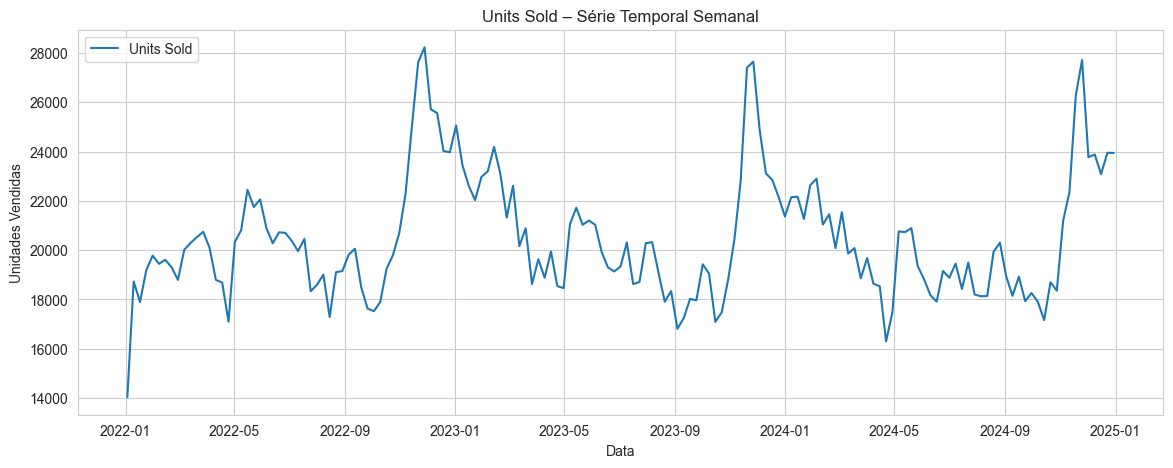

In [127]:

plt.figure(figsize=(14, 5))
plt.plot(y, label="Units Sold")
plt.title("Units Sold – Série Temporal Semanal")
plt.ylabel("Unidades Vendidas")
plt.xlabel("Data")
plt.legend()
plt.show()


#### 5.2.1 - Decomposição de Série Temporal do Target

- Verificação do crescimento orgânico da varejo360 (Tendência)
- Observação do impacto causado pela sazonalidade
- Identificação de resíduos que podem ser picos causados pelas campanhas de Marketing ou Outliers

**Escolha do STL (Seasonal and Trend decomposition using Loess)** <br>
STL é preferível ao seasonal_decompose porque é mais robusto a outliers típicos de picos de mídia, estima melhor tendências <br>
não lineares e permite modelar sazonalidade anual em séries semanais de forma mais estável, evitando viés nos coeficientes do modelo.

Hiperparâmetros utilizados:
- period = 52 → sazonalidade anual (365 dias ~ 52 semanas)
- robust = True → Captura picos de mídia, promoções atípicas e eventos únicos como resíduos (não influenciam tendência e sazonalidade)

In [128]:
stl = STL(
    y,
    period=52,
    robust=True
)

result = stl.fit()

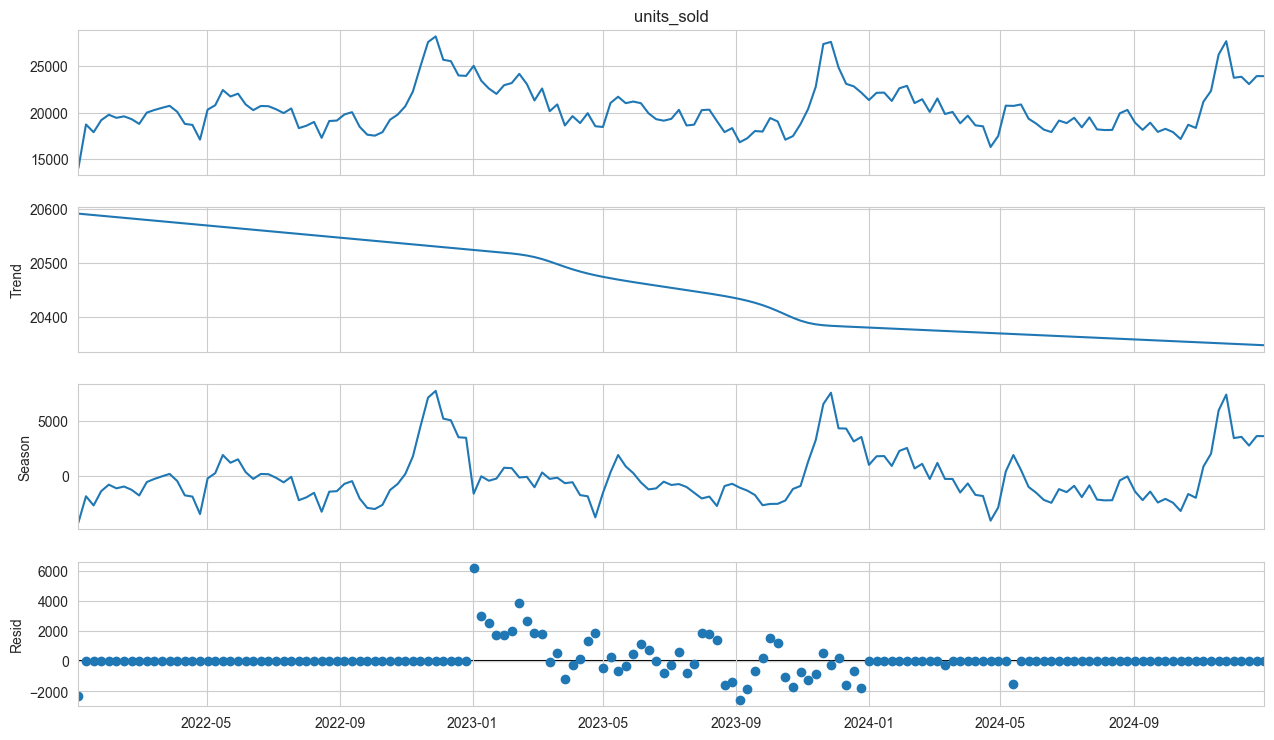

In [129]:
fig = result.plot()
fig.set_size_inches(14, 8)
plt.show()

In [130]:
# Criando dataframe com os componentes da decomposição para análises posteriores
df_decomp = pd.DataFrame({
    "units_sold": y,
    "trend": result.trend,
    "seasonality": result.seasonal,
    "residual": result.resid
})

#### 5.2.2 - Análise da **Tendência**

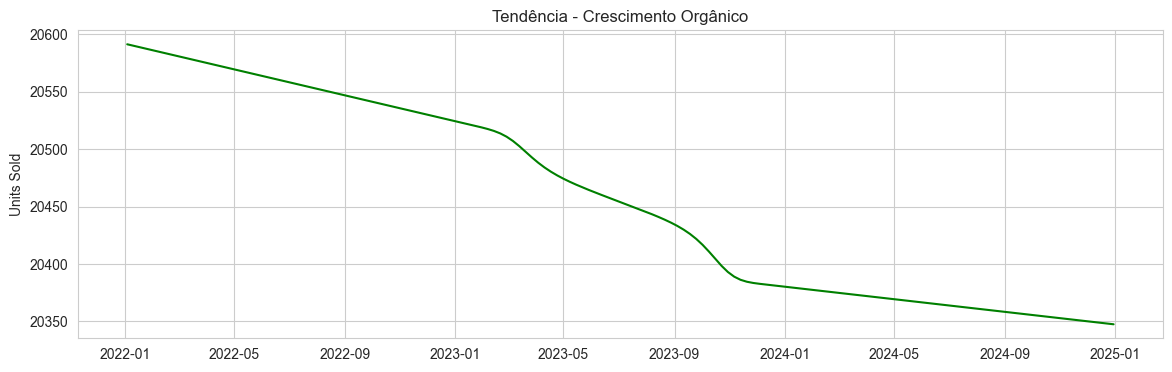

In [131]:
plt.figure(figsize=(14, 4))
plt.plot(df_decomp["trend"], color="green")
plt.title("Tendência - Crescimento Orgânico")
plt.ylabel("Units Sold")
plt.show()

Verifica-se uma queda ao longo do período analisado, contudo, isso representa uma queda de apenas 1.23% durante os 3 anos observados.

#### 5.2.3 - Análise de **Sazonalidade**

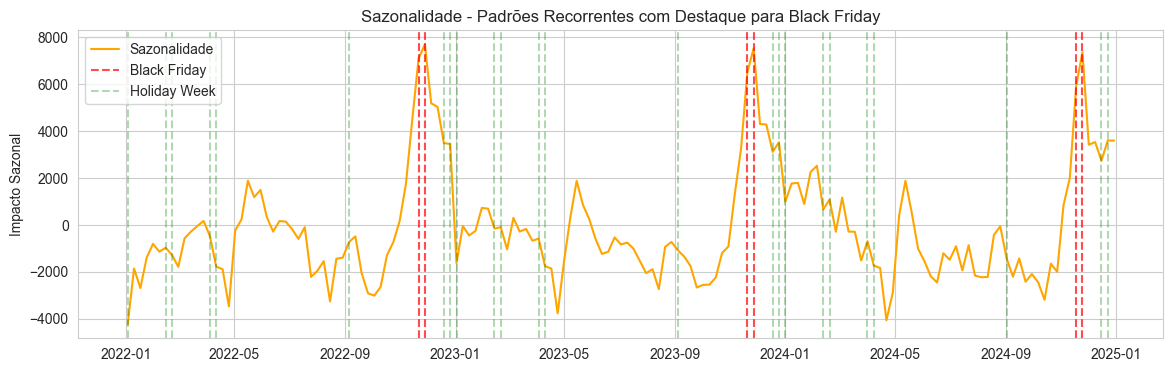

In [132]:


fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_decomp.index, df_decomp["seasonality"], label="Sazonalidade", color="orange")

for i, d in enumerate(datas_black_friday):
    ax.axvline(
        d,
        color="red",
        linestyle="--",
        alpha=0.7,
        label="Black Friday" if i == 0 else None
    )
    
for i, d in enumerate(datas_holiday_week):
    ax.axvline(
        d,
        color="green",
        linestyle="--",
        alpha=0.3,
        label="Holiday Week" if i == 0 else None
    )

ax.set_title("Sazonalidade - Padrões Recorrentes com Destaque para Black Friday")
ax.set_ylabel("Impacto Sazonal")
ax.legend(loc='upper left')

plt.show()


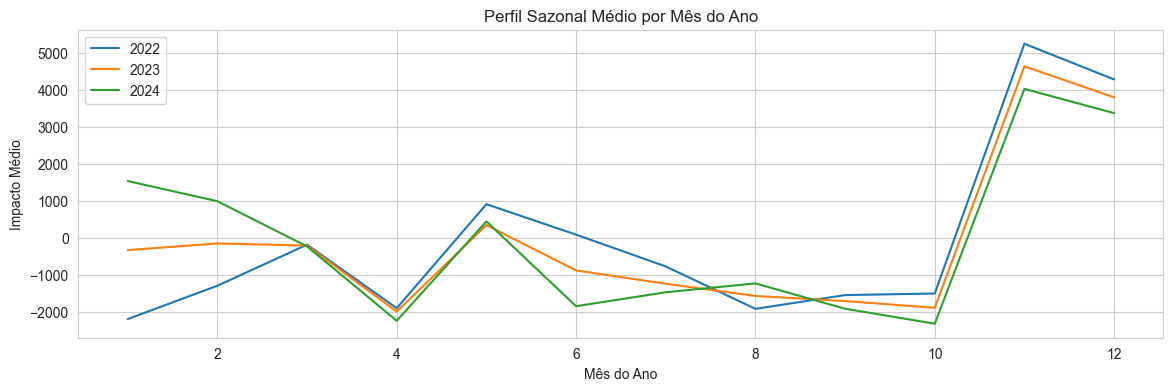

In [133]:
season_month = df_decomp.groupby(
    [df_decomp.index.month, df_decomp.index.year]
).agg({'seasonality': 'mean'})['seasonality'].unstack(level=1)

plt.figure(figsize=(14, 4))
plt.plot(season_month, label=season_month.columns.values)
plt.title("Perfil Sazonal Médio por Mês do Ano")
plt.xlabel("Mês do Ano")
plt.ylabel("Impacto Médio")
plt.legend()
plt.show()

#### 5.2.4 - Análise dos **Resíduos**

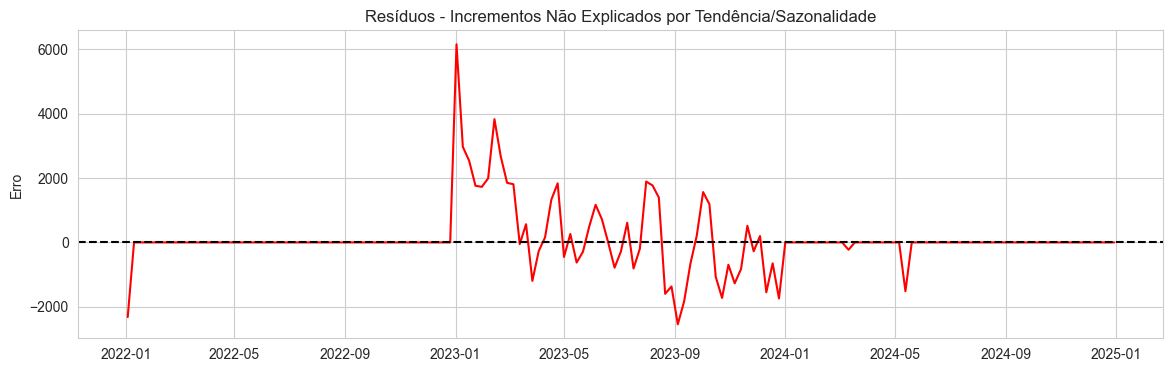

In [134]:
plt.figure(figsize=(14, 4))
plt.plot(df_decomp["residual"], color="red")
plt.axhline(0, linestyle="--", color="black")
plt.title("Resíduos - Incrementos Não Explicados por Tendência/Sazonalidade")
plt.ylabel("Erro")
plt.show()


In [135]:
threshold = df_decomp["residual"].std() * 2.5

outliers = df_decomp[
    np.abs(df_decomp["residual"]) > threshold
]

outliers[["units_sold", "residual"]]

,units_sold,residual
date,,
2023-01-02,25059,6158.790544
2023-01-09,23449,2970.917305
2023-01-16,22609,2537.247910
2023-02-13,24191,3831.163665
2023-02-20,23087,2669.862816
2023-09-04,16811,-2544.987777


In [136]:
adf_result = adfuller(df_decomp["residual"].dropna())

print(f"ADF Statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.5f}")

ADF Statistic: -2.813
p-value: 0.05638


O teste ADF aplicado aos resíduos da decomposição STL resultou em um p-value marginalmente acima de 5%, sugerindo uma leve evidência de não estacionariedade. Dado o tamanho reduzido da amostra e a presença de eventos promocionais recorrentes, esse resultado é interpretado como aceitável no contexto de MMM, indicando que a maior parte da estrutura temporal foi adequadamente removida, restando variação compatível com efeitos incrementais e ruído.

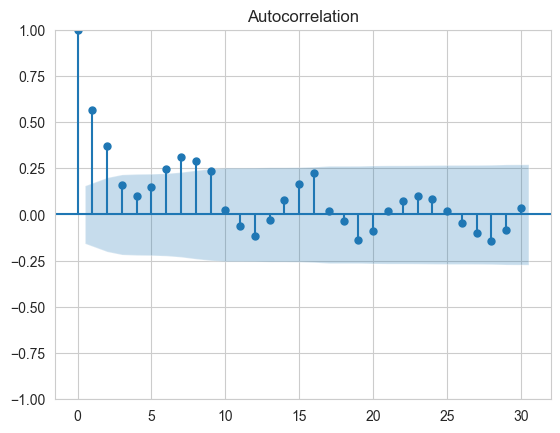

In [137]:

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df_decomp["residual"].dropna(), lags=30)
plt.show()


Apesar de o teste ADF não rejeitar formalmente a hipótese de não estacionariedade a 5%, o resultado marginal, aliado à inspeção visual e ao contexto do negócio, sugere que os resíduos são suficientemente estacionários para servir de base ao MMM, sem evidência de viés estrutural relevante.

### Realizando o pré-tratamento da Black-Friday

Embora a Black Friday apresente caráter recorrente, sua intensidade e sincronização com investimentos de mídia variam ao longo do tempo. Por isso, optou-se por tratá-la como um evento exógeno via variável dummy, evitando que seu impacto fosse absorvido indevidamente pela sazonalidade.

In [138]:
df_clean = df.copy()

In [139]:
from pandas.tseries.offsets import Week

bf_dates = pd.to_datetime(datas_black_friday)

df_clean["bf_window"] = 0

for bf in bf_dates:
    window = pd.date_range(
        bf - Week(2),
        bf + Week(2),
        freq="W-MON"  # importante: alinhar com seu calendário
    )
    df_clean.loc[df_clean.index.isin(window), "bf_window"] = 1


In [140]:
bf_effect = (
    df_clean.loc[df_clean["bf_window"] == 1, "units_sold"].mean()
    - df_clean.loc[df_clean["bf_window"] == 0, "units_sold"].mean()
)

df_clean["units_sold_adj"] = df_clean["units_sold"] - df_clean["bf_window"] * bf_effect

In [141]:
bf_effect

np.float64(4896.734612310152)

In [142]:
from statsmodels.tsa.seasonal import STL

stl_adj = STL(
    df_clean["units_sold_adj"],
    period=52,
    robust=True
)

result_adj = stl_adj.fit()

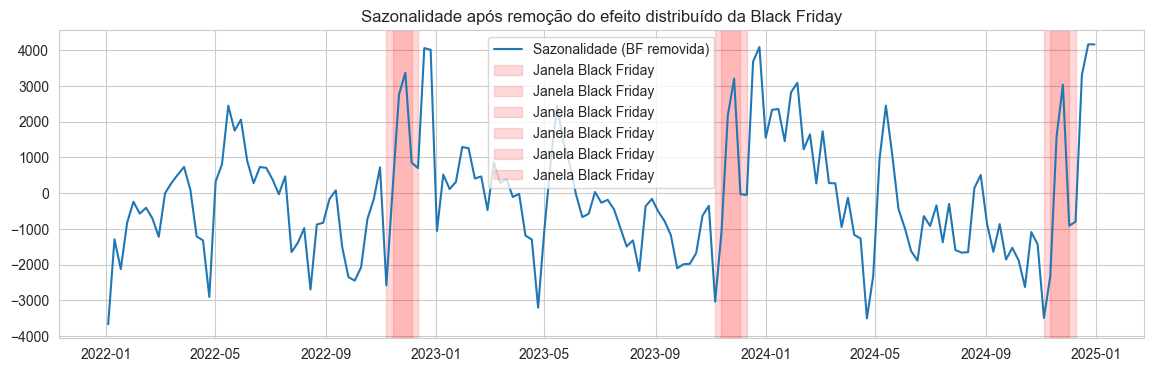

In [145]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_clean.index, result_adj.seasonal, label="Sazonalidade (BF removida)")

for bf in bf_dates:
    ax.axvspan(
        bf - Week(2),
        bf + Week(2),
        color="red",
        alpha=0.15,
        label="Janela Black Friday"
    )

ax.set_title("Sazonalidade após remoção do efeito distribuído da Black Friday")
ax.legend()
plt.show()

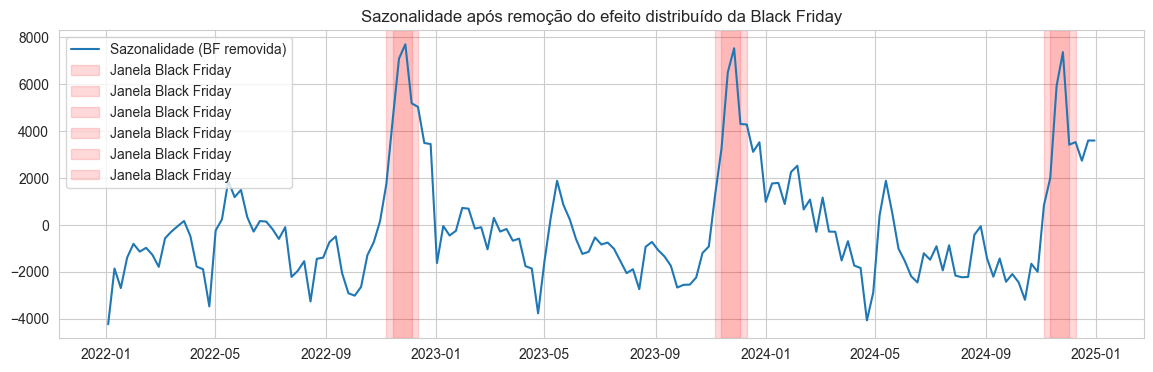

In [144]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df.index, result.seasonal, label="Sazonalidade (BF removida)")

for bf in bf_dates:
    ax.axvspan(
        bf - Week(2),
        bf + Week(2),
        color="red",
        alpha=0.15,
        label="Janela Black Friday"
    )

ax.set_title("Sazonalidade após remoção do efeito distribuído da Black Friday")
ax.legend()
plt.show()